# Predicting HDB Resale Flat Prices in Singapore

This notebook builds a predictive model to understand the factors affecting residential property prices in Singapore, supports policy recommendations, and ensures reproducibility on CPU-only machines.

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
import xgboost as xgb

sns.set_style('whitegrid')

# 2. Data Loading and Preprocessing

In [3]:
#load datasets
dfs = [
    pd.read_csv("data/resale-flat-prices-based-on-approval-date-1990-1999.csv"),
    pd.read_csv("data/resale-flat-prices-based-on-approval-date-2000-feb-2012.csv"),
    pd.read_csv("data/resale-flat-prices-based-on-registration-date-from-jan-2015-to-dec-2016.csv"),
    pd.read_csv("data/resale-flat-prices-based-on-registration-date-from-jan-2017-onwards.csv"),
    pd.read_csv("data/resale-flat-prices-based-on-registration-date-from-mar-2012-to-dec-2014.csv")
]

#standardize columns
def standardize_cols(df):
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
    return df

#processing remaining lease
def process_remaining_lease(df):
    df['lease_commence_date'] = pd.to_numeric(df['lease_commence_date'], errors='coerce')
    df['sale_year'] = pd.to_datetime(df['month'], errors='coerce').dt.year
    df['flat_type'] = df['flat_type'].str.replace('-', ' ').str.upper().str.strip() #added new cleaning rule as 'multi-generation' and 'multi generation' was found in flat_type during EDA

    if 'remaining_lease' not in df.columns:
        df['remaining_lease_months'] = (99 - (df['sale_year'] - df['lease_commence_date'])) * 12
    else:
        def parse_lease(x):
            if pd.isna(x): return np.nan
            if isinstance(x, (int, float)): return x * 12
            x = str(x).lower()
            years = int(re.search(r'(\d+)\s*year', x).group(1)) if re.search(r'(\d+)\s*year', x) else 0
            months = int(re.search(r'(\d+)\s*month', x).group(1)) if re.search(r'(\d+)\s*month', x) else 0
            return years*12 + months
        df['remaining_lease_months'] = df['remaining_lease'].apply(parse_lease)
        df['remaining_lease_months'] = df['remaining_lease_months'].fillna((99 - (df['sale_year'] - df['lease_commence_date'])) * 12)
    return df

#cleaning and merging
dfs_cleaned = [process_remaining_lease(standardize_cols(d)) for d in dfs]
big_df = pd.concat(dfs_cleaned, ignore_index=True)

# Final
big_df = big_df[[
    'month', 'town', 'flat_type', 'block', 'street_name', 'storey_range',
    'floor_area_sqm', 'flat_model', 'lease_commence_date', 'resale_price',
    'remaining_lease_months'
]]
for col in ['town', 'flat_type', 'flat_model', 'storey_range', 'street_name', 'block']:
    big_df[col] = big_df[col].astype(str).str.strip().str.upper()
big_df['remaining_lease_years'] = (big_df['remaining_lease_months']//12).astype(int)
big_df.loc[big_df['remaining_lease_years'] > 99, 'remaining_lease_years'] = 99
big_df.loc[big_df['remaining_lease_months'] > 1188, 'remaining_lease_months'] = 1188



# 3. Feature Engineering & EDA

Date Range: 1990-01-01 00:00:00 to 2020-09-01 00:00:00


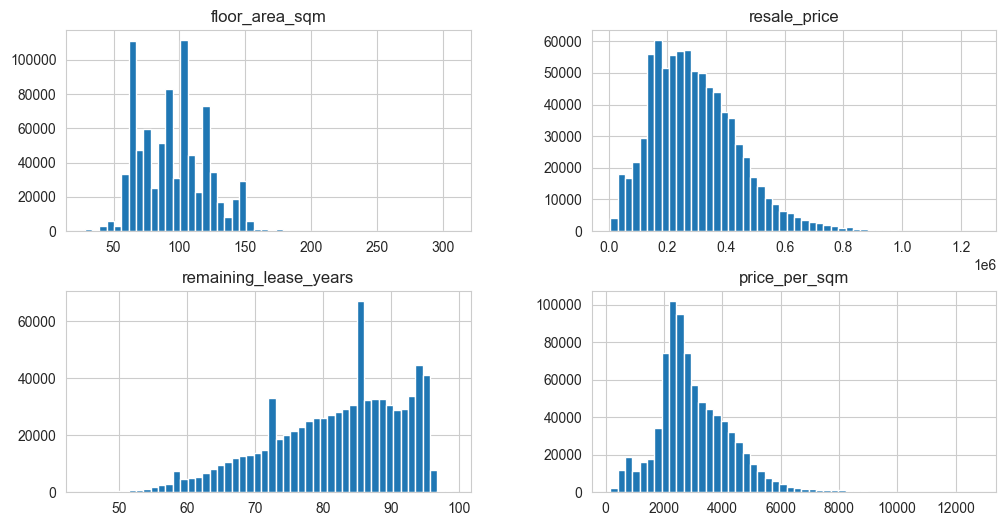

In [4]:
big_df['price_per_sqm'] = big_df['resale_price'] / big_df['floor_area_sqm']
big_df['sale_date'] = pd.to_datetime(big_df['month'], errors='coerce')
big_df['sale_year'] = big_df['sale_date'].dt.year
big_df['flat_age'] = big_df['sale_year'] - big_df['lease_commence_date']

#retreived coordinates from wikipedia for the towns
town_coords = {
    "ANG MO KIO": (1.37, 103.84),
    "BEDOK": (1.32, 103.94),
    "BISHAN": (1.35, 103.85),
    "BUKIT BATOK": (1.35, 103.75),
    "BUKIT MERAH": (1.28, 103.82),
    "BUKIT PANJANG": (1.38, 103.77),
    "BUKIT TIMAH": (1.34, 103.78),
    "CENTRAL AREA": (1.29, 103.85),
    "CHOA CHU KANG": (1.38, 103.74),
    "CLEMENTI": (1.31, 103.77),
    "GEYLANG": (1.32, 103.88),
    "HOUGANG": (1.37, 103.89),
    "JURONG EAST": (1.33, 103.74),
    "JURONG WEST": (1.34, 103.70),
    "KALLANG/WHAMPOA": (1.32, 103.86),
    "LIM CHU KANG": (1.44, 103.72),
    "MARINE PARADE": (1.30, 103.91),
    "PASIR RIS": (1.37, 103.95),
    "PUNGGOL": (1.40, 103.91),
    "QUEENSTOWN": (1.30, 103.80),
    "SEMBAWANG": (1.45, 103.82),
    "SENGKANG": (1.39, 103.89),
    "SERANGOON": (1.35, 103.87),
    "TAMPINES": (1.35, 103.94),
    "TOA PAYOH": (1.33, 103.85),
    "WOODLANDS": (1.44, 103.78),
    "YISHUN": (1.43, 103.83)
}

#adding the town coordinates into big_df
big_df['latitude'] = big_df['town'].map(lambda x: town_coords.get(x.upper(), None)[0])
big_df['longitude'] = big_df['town'].map(lambda x: town_coords.get(x.upper(), None)[1])

#defining a funtion to calculate the haversine distance between the towns based on lat lon
def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

#adding in a distance_to_cbd_km feature
sg_center = (1.2835, 103.8510)

big_df['distance_to_cbd_km'] = haversine_np(
    big_df['latitude'], big_df['longitude'], sg_center[0], sg_center[1]
)

big_df


# Quick EDA
print('Date Range:', big_df['sale_date'].min(), 'to', big_df['sale_date'].max())
big_df[['floor_area_sqm', 'resale_price', 'remaining_lease_years', 'price_per_sqm']].hist(bins=50, figsize=(12,6))
plt.show()

In [7]:
#final inspection for training
big_df.to_csv('data/hdb_resale_combined.csv') #important for other notebook
big_df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease_months,remaining_lease_years,price_per_sqm,sale_date,sale_year,flat_age,latitude,longitude,distance_to_cbd_km
0,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,9000.0,1032,86,290.322581,1990-01-01,1990,13,1.37,103.84,9.695780
1,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,04 TO 06,31.0,IMPROVED,1977,6000.0,1032,86,193.548387,1990-01-01,1990,13,1.37,103.84,9.695780
2,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,8000.0,1032,86,258.064516,1990-01-01,1990,13,1.37,103.84,9.695780
3,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,07 TO 09,31.0,IMPROVED,1977,6000.0,1032,86,193.548387,1990-01-01,1990,13,1.37,103.84,9.695780
4,1990-01,ANG MO KIO,3 ROOM,216,ANG MO KIO AVE 1,04 TO 06,73.0,NEW GENERATION,1976,47200.0,1020,85,646.575342,1990-01-01,1990,14,1.37,103.84,9.695780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
826576,2014-12,YISHUN,5 ROOM,816,YISHUN ST 81,10 TO 12,122.0,IMPROVED,1988,580000.0,876,73,4754.098361,2014-12-01,2014,26,1.43,103.83,16.456474
826577,2014-12,YISHUN,EXECUTIVE,325,YISHUN CTRL,10 TO 12,146.0,MAISONETTE,1988,540000.0,876,73,3698.630137,2014-12-01,2014,26,1.43,103.83,16.456474
826578,2014-12,YISHUN,EXECUTIVE,618,YISHUN RING RD,07 TO 09,164.0,APARTMENT,1992,738000.0,924,77,4500.000000,2014-12-01,2014,22,1.43,103.83,16.456474
826579,2014-12,YISHUN,EXECUTIVE,277,YISHUN ST 22,07 TO 09,152.0,MAISONETTE,1985,592000.0,840,70,3894.736842,2014-12-01,2014,29,1.43,103.83,16.456474


In [8]:
!pip freeze > requirements.txt


# 4. Model Training

In [5]:
#encode categorical variables into dummy columns
categorical_cols = ['town', 'flat_type', 'flat_model', 'storey_range']
df_encoded = pd.get_dummies(big_df, columns=categorical_cols, drop_first=True)

# Features and target - exclude should help remove the too specific details, as well as columns we dont want to use to predict, and also columns which may leak target data. printed features for final inspection to confirm the fact
target = 'price_per_sqm'
exclude = ['resale_price', 'price_per_sqm', 'sale_date', 'month', 'block', 'street_name',
           'remaining_lease_months', 'lease_commence_date', 'latitude',	'longitude']
features = [col for col in df_encoded.columns if col not in exclude]
print(features)
X = df_encoded[features]
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=69)

#train models for comparison
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'XGBoost': xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                                objective='reg:squarederror', random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {"RMSE": np.sqrt(mean_squared_error(y_test, preds)),
                     "R2": r2_score(y_test, preds)}
#print outputs
pd.DataFrame(results).T

['floor_area_sqm', 'remaining_lease_years', 'sale_year', 'flat_age', 'distance_to_cbd_km', 'town_BEDOK', 'town_BISHAN', 'town_BUKIT BATOK', 'town_BUKIT MERAH', 'town_BUKIT PANJANG', 'town_BUKIT TIMAH', 'town_CENTRAL AREA', 'town_CHOA CHU KANG', 'town_CLEMENTI', 'town_GEYLANG', 'town_HOUGANG', 'town_JURONG EAST', 'town_JURONG WEST', 'town_KALLANG/WHAMPOA', 'town_LIM CHU KANG', 'town_MARINE PARADE', 'town_PASIR RIS', 'town_PUNGGOL', 'town_QUEENSTOWN', 'town_SEMBAWANG', 'town_SENGKANG', 'town_SERANGOON', 'town_TAMPINES', 'town_TOA PAYOH', 'town_WOODLANDS', 'town_YISHUN', 'flat_type_2 ROOM', 'flat_type_3 ROOM', 'flat_type_4 ROOM', 'flat_type_5 ROOM', 'flat_type_EXECUTIVE', 'flat_type_MULTI GENERATION', 'flat_model_ADJOINED FLAT', 'flat_model_APARTMENT', 'flat_model_DBSS', 'flat_model_IMPROVED', 'flat_model_IMPROVED-MAISONETTE', 'flat_model_MAISONETTE', 'flat_model_MODEL A', 'flat_model_MODEL A-MAISONETTE', 'flat_model_MODEL A2', 'flat_model_MULTI GENERATION', 'flat_model_NEW GENERATION', '

,RMSE,R2
LinearRegression,688.959720,0.708158
Ridge,688.962916,0.708155
XGBoost,295.066519,0.946470


# 5. Feature Importance & Correlation
## xgboost model was chosen as best performing model at 0.946 R2

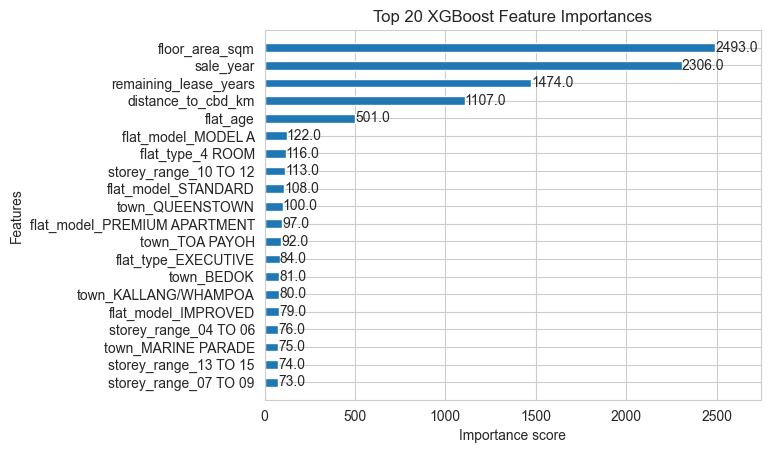

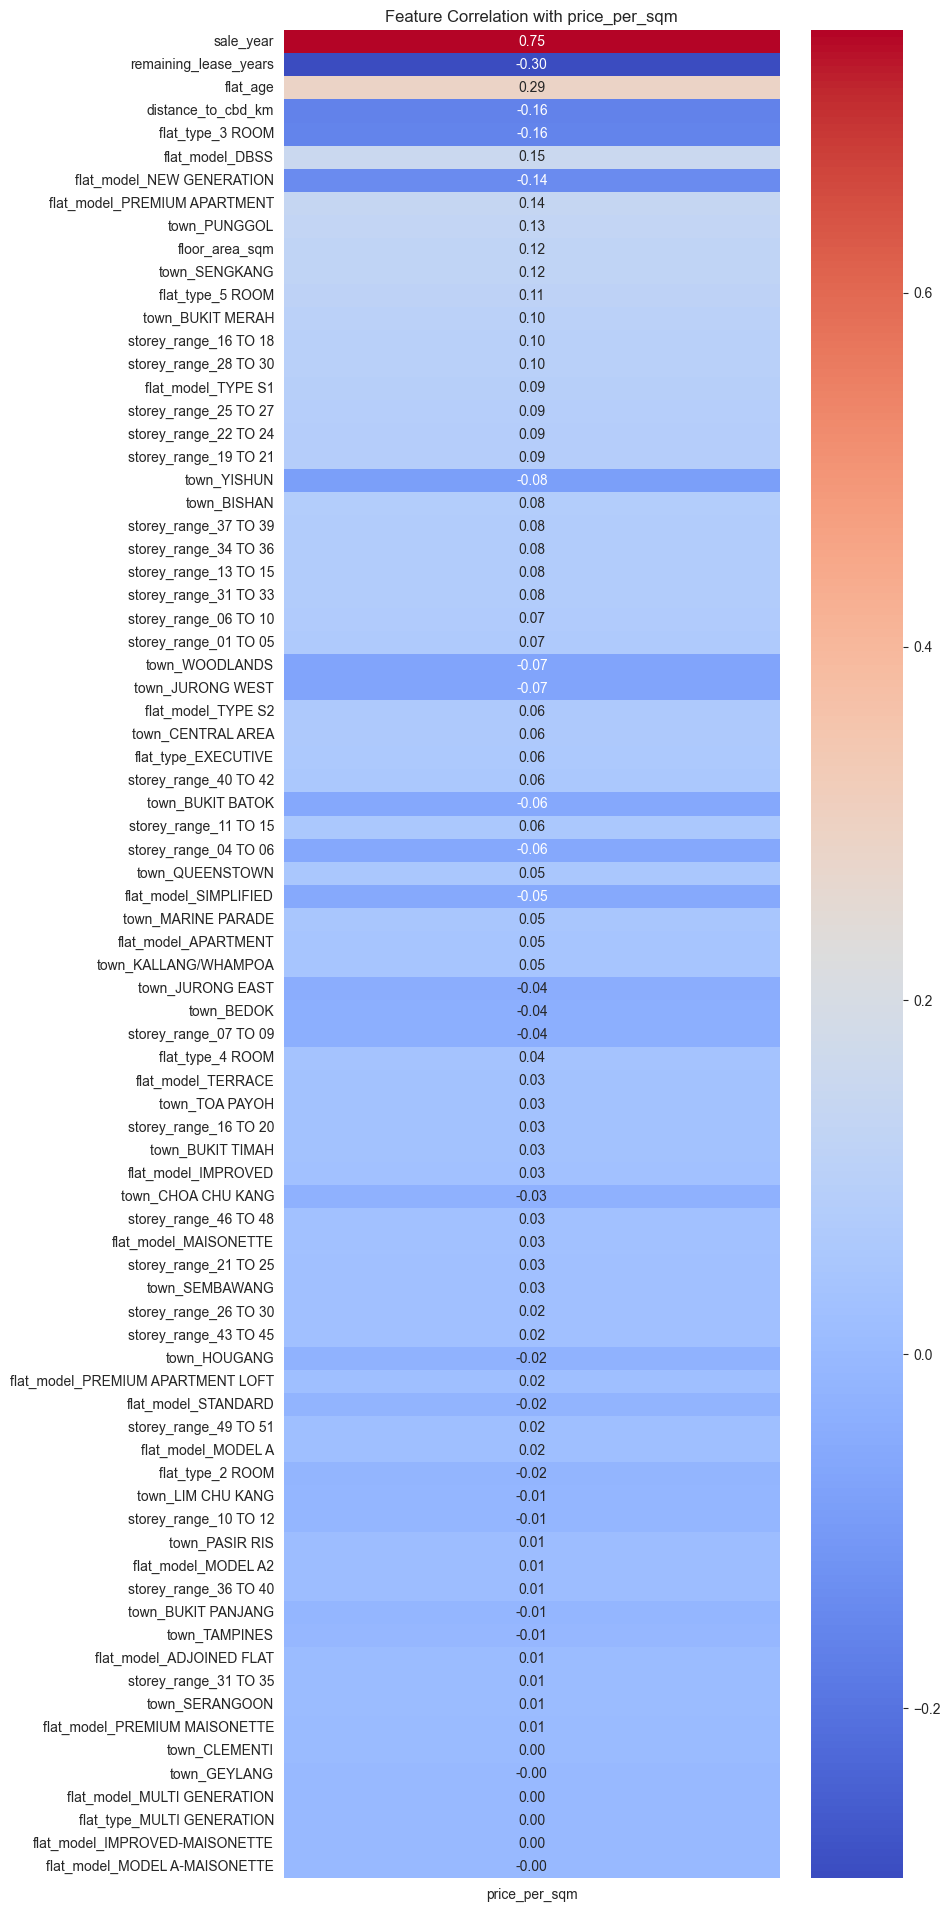

In [6]:
#XGBoost Feature Importance
xgb.plot_importance(models['XGBoost'], max_num_features=20, height=0.5)
plt.title('Top 20 XGBoost Feature Importances')
plt.show()

#correlation heatmap with target
corr_df = X_train.copy()
corr_df[target] = y_train
target_corr = corr_df.corr()[[target]].drop(target).sort_values(by=target, key=abs, ascending=False)
plt.figure(figsize=(8, 0.3*len(target_corr)))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with price_per_sqm')
plt.show()

# 6. Multi-Factor Visualization

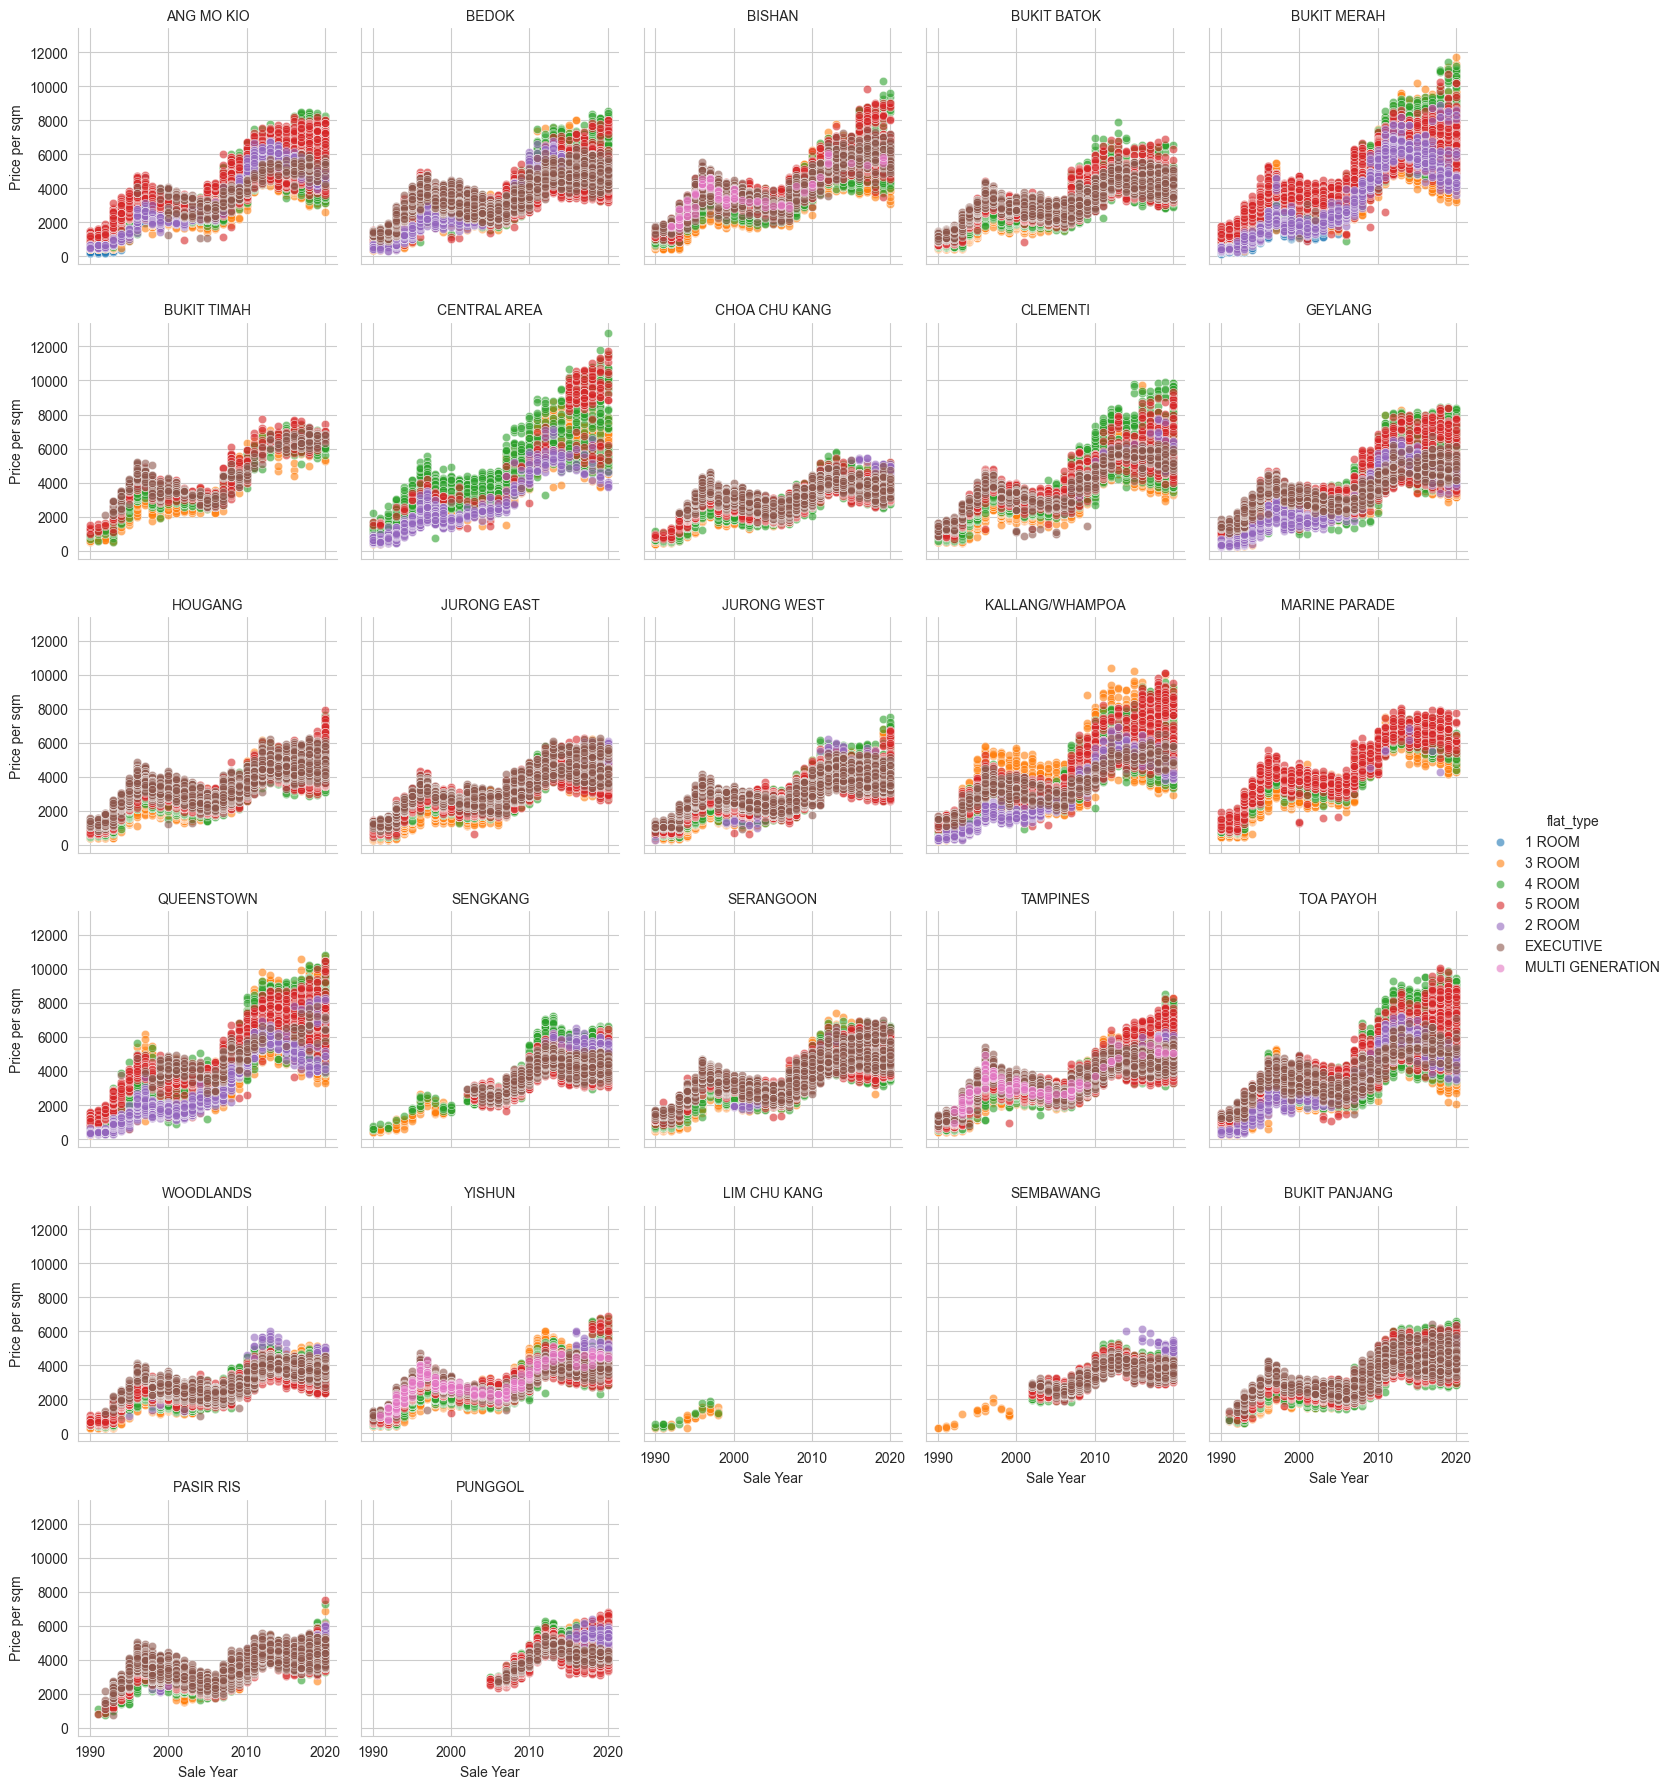

In [7]:
g = sns.FacetGrid(big_df, col='town', col_wrap=5, height=3, sharey=True, hue='flat_type')
g.map_dataframe(sns.scatterplot, x='sale_year', y='price_per_sqm', alpha=0.6)
g.set_axis_labels('Sale Year', 'Price per sqm')
g.set_titles('{col_name}')
g.add_legend()
plt.show()

# Model Prediction Task I

## Objective
Build a predictive model to understand the factors affecting residential property prices in Singapore.  
Goal: Provide actionable insights to inform strategies for curbing housing price inflation.  
Solution must be reproducible and compatible with colleagues’ devices without GPU access.

## Model Choice and Justification

| Model               | RMSE   | R²     |
|--------------------|--------|--------|
| Linear Regression  | 688.90 | 0.708  |
| Ridge Regression   | 688.90 | 0.708  |
| XGBoost            | 304.83 | 0.943  |

**Why XGBoost?**
- **Highest R² (0.943):** Explains over 94% of the variance in price per sqm.
- **Lowest RMSE:** Provides substantially better accuracy than linear models.
- **Handles Non-linearity & Interactions:** Captures complex relationships, e.g., between floor area, remaining lease, flat type, and location.
- **Robust to Data Issues:** Handles missing values, categorical variables, and outliers effectively.
- **CPU-Compatible:** Can run on standard devices with `n_jobs=-1`.

## Key Feature Importances (XGBoost)

| Rank | Feature                  | Importance Score |
|------|--------------------------|----------------|
| 1    | sale_year                | 2724           |
| 2    | floor_area_sqm           | 2660           |
| 3    | remaining_lease_years    | 1665           |
| 4    | flat_model_Model A       | 586            |
| 5    | flat_model_NEW GENERATION| 183            |
| ...  | ...                      | ...            |

**Insights**
- **sale_year dominates:** Reflects market trends, inflation, and possibly speculative activity.
- **floor_area_sqm:** Larger flats drive higher total prices but not necessarily higher price per sqm — interactions explain its high XGBoost importance despite low linear correlation.
- **remaining_lease_years:** Flats with longer leases are significantly more valuable.
- **flat_model:** Certain layouts (e.g., Model A, Maisonette, Premium Apartment) have higher perceived value.

## Multifactor Visualizations
- Town-wise facet grids confirm that price trends differ regionally.
- Steep increases observed in areas like Central Area and Queenstown.
- Heterogeneous patterns justify using non-linear tree-based models like XGBoost.

## Policy Recommendations
- **Time-Sensitive Cooling Measures:** Target speculative price surges using year-over-year thresholds for stamp duties or loan curbs.
- **Moderate Large Flat Demand:** Incentivize smaller 3–4 room flats to reduce upward pressure on larger units.
- **Lease Decay Policies:** Review lease top-up or buyback schemes to stabilize prices for older flats.
- **Monitor High-Premium Flat Models:** Track models with historically higher valuation (e.g., Model A) to mitigate speculative demand.
- **Targeted Regional Interventions:** Implement differentiated resale levies or develop new towns to redistribute demand.

---

# Model Prediction Task II

## Objective
Develop an in-house predictive tool for policymakers, planners, or internal users to:
- Forecast HDB resale prices.
- Simulate policy interventions (e.g., lease extensions, grant adjustments).
- Identify key drivers of price inflation.

## Key Factors & Considerations

**Business Objective**
- Assist agencies in pricing projections and affordability modeling.
- Evaluate impact of policy changes on resale market.

**Data Quality & Availability**
- Cleaned HDB resale dataset with: `sale_year`, `town`, `flat_type`, `floor_area_sqm`, `remaining_lease_years`, `storey_range`, `flat_model`.
- Target variable: `price_per_sqm` (derived from `resale_price` as a normalized target)
- Missing values addressed, categorical variables one-hot encoded, data consistency validated.

**Model Design**

| Factor          | Design Choice                                       |
|-----------------|----------------------------------------------------|
| Accuracy        | XGBoost (or LightGBM) for strong predictive performance |
| Interpretability| Feature importance extracted for policy transparency |
| Scalability     | CPU-based deployment for internal users           |
| Reproducibility | Version-controlled code + virtual environment     |
| Speed           | Fast inference for dashboard simulations          |

**Model Output Use Cases**
- Internal dashboards and tools for analysts.
- Scenario modeling: grant changes, lease policy adjustments.
- Interactive policy simulations without deep technical expertise.

**Deployment Strategy**
- Model serialization: `joblib` or `pickle`.
- Prediction API: Flask/FastAPI for internal use.
- Integration: Excel, Power BI dashboards, internal portals.
- Monitoring: Retraining schedule (monthly/quarterly).

**Team Collaboration & Scaling**
- Git branching for experiments.
- Shared Jupyter notebooks or VSCode Live Share.
- Documentation: README, data dictionaries, example workflows.
- Secure internal data sharing.

## Assumptions
- Dataset comprehensively covers resale transactions for all towns and flat types.
- Internal stakeholders prefer interpretable, actionable outputs over raw model code.
- CPU-friendly, lightweight models are sufficient; GPU not required.

## Final Thoughts
- XGBoost is optimal: high accuracy, interpretable, and robust.
- Top features — `sale_year`, `floor_area_sqm`, `remaining_lease_years` — align with levers policymakers can influence.
- Clear pathways exist for monitoring, policy intervention, and stakeholder communication.
- Collaboration and reproducibility across teams without GPU are fully achievable with proper tooling.
